In [2]:
%load_ext autoreload
%autoreload 2
import sys
from rdkit import Chem
sys.path.append('src')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from src import MoleculeRenderer


def draw_mol(mol, title="", highlight_atoms=None, highlight_bonds=None, display_props=None):
    mr = MoleculeRenderer()
    display(mr.render_2d(mol, title, highlight_atoms, highlight_bonds, display_props))



=== Тестирование MoleculeRenderer ===


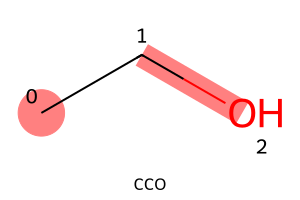

2D рендеринг выполнен


In [4]:
# Тестирование модуля visualization.molecule_renderer
print("\n=== Тестирование MoleculeRenderer ===")


def test_molecule_renderer():
    cco = 'CCO'
    mock_molecule = Chem.MolFromSmiles(cco)
    highlight_atoms = [0]
    highlight_bounds = [1]
    # Тест 2D рендеринга
    render_2d = draw_mol(mock_molecule, cco, highlight_atoms, highlight_bounds)

    return render_2d


test_molecule_renderer()
print("2D рендеринг выполнен")


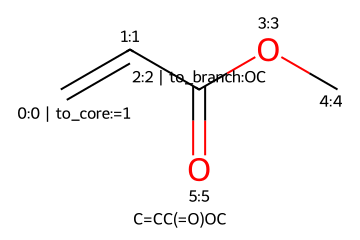

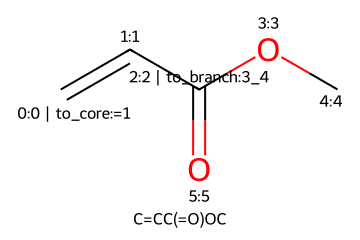

In [5]:
def freeze_original_index(mol):
    for i, atom in enumerate(mol.GetAtoms()):
        atom.SetProp("original_index", str(i))  # Зафриженный исходный индекс


def create_methyl_acrylate_with_metadata_smiles():
    return create_methyl_acrylate_with_metadata("OC")


def create_methyl_acrylate_with_metadata_indexes():
    return create_methyl_acrylate_with_metadata("3_4")


def create_methyl_acrylate_with_metadata(tail):
    """Создаем молекулу метилакрилата с метаданными о точках соединения"""
    smiles = "C=CC(OC)=O"
    mol = Chem.MolFromSmiles(smiles)

    # connection_atoms: [0, 2]
    # Первый атом (0) - для соединения с основой
    # Второй атом (2) - для присоединения продолжения ветви
    connection_atoms = [0, 2]
    replacement_groups = ["=1", tail]

    freeze_original_index(mol)

    for i, atom_idx in enumerate(connection_atoms):
        methyl_acrylate_atom = mol.GetAtomWithIdx(atom_idx)
        methyl_acrylate_atom.SetProp("is_connection", "true")
        methyl_acrylate_atom.SetProp("replacement_group", replacement_groups[i])

        # Размечаем тип точки соединения
        if i == 0:
            methyl_acrylate_atom.SetProp("connection_type", "to_core")  # Для соединения с основой
        else:
            methyl_acrylate_atom.SetProp("connection_type", "to_branch")  # Для присоединения продолжения

    return mol


methyl_acrylate = create_methyl_acrylate_with_metadata_smiles()
draw_mol(methyl_acrylate, display_props=["original_index", "connection_type", "replacement_group"])

methyl_acrylate_i = create_methyl_acrylate_with_metadata_indexes()
draw_mol(methyl_acrylate_i, display_props=["original_index", "connection_type", "replacement_group"])

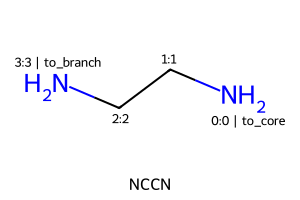

In [6]:

def create_ethylenediamine_with_metadata():
    """Создаем молекулу этилендиамина с метаданными о точках соединения"""
    smiles = "NCCN"
    ethylenediamine_mol = Chem.MolFromSmiles(smiles)

    freeze_original_index(ethylenediamine_mol)
    # connection_atoms: [0, 0, 3]
    # Первый атом (0) - для соединения с основой
    # Остальные (0, 3) - для присоединения продолжения ветви
    connection_atoms = [0, 3]
    replacement_groups = ["H", "H"]

    for i, atom_idx in enumerate(connection_atoms):
        ethylenediamine_atom = ethylenediamine_mol.GetAtomWithIdx(atom_idx)
        ethylenediamine_atom.SetProp("is_connection", "true")
        ethylenediamine_atom.SetProp("replacement_group", replacement_groups[i])

        if i == 0:
            ethylenediamine_atom.SetProp("connection_type", "to_core")  # К основе
        else:
            ethylenediamine_atom.SetProp("connection_type", "to_branch")  # К продолжению ветви

    return ethylenediamine_mol


ethylenediamine = create_ethylenediamine_with_metadata()
draw_mol(ethylenediamine, display_props=["original_index", "connection_type"])

=== Тестирование ChemistryOperations ===
=== Тест на хвост молекулы methyl_acrylate с smiles ===


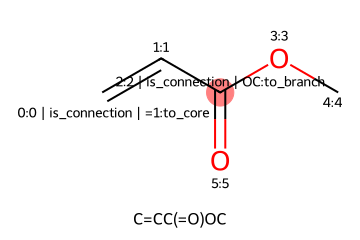


Детальный анализ структуры
Атом соединения: C(2)
Replacement group: OC

Структура replacement_group:
   Атом 0: O → соседи: ['C(1)']
   Атом 1: C → соседи: ['O(0)']

Соседи атома соединения:
   Сосед 0: C(1) → соседи: ['C(0)']
   Сосед 1: O(3) → соседи: ['C(4)']
   Сосед 2: O(5) → соседи: []

Поиск соответствующей ветки:
   Первый атом replacement: O, степень: 1

   Найден кандидат: O(3)
   Правильная ветка найдена: [3, 4]

Результат: Атомы для удаления: [3, 4]


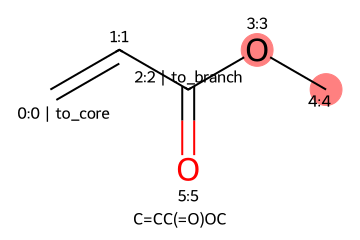

=== Тест на удаление хвоста молекулы methyl_acrylate с smiles ===

Детальный анализ структуры
Атом соединения: C(2)
Replacement group: 3_4

Соседи атома соединения:
   Сосед 0: C(1) → соседи: ['C(0)']
   Сосед 1: O(3) → соседи: ['C(4)']
   Сосед 2: O(5) → соседи: []
Атомы хвоста по original_index: [3, 4]

=== ВЫПОЛНЕНИЕ REDUCE ===
Атомы для удаления: [3, 4]
Связь для разрыва: None
Удалены атомы: [3, 4]
Reduce завершен успешно


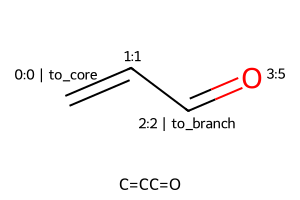

In [7]:
print("=== Тестирование ChemistryOperations ===")

from src.core.chemistry_operations import ChemistryOperations


def test_methyl_acrylate():
    print("=== Тест на хвост молекулы methyl_acrylate с smiles ===")

    mol = create_methyl_acrylate_with_metadata_smiles()
    co = ChemistryOperations()
    draw_mol(mol, highlight_atoms=[2],
             display_props=['original_index', "is_connection", "replacement_group", "connection_type"])
    # Анализируем структуру
    result = co.analyze_replacement_structure(mol, 2)

    print(f"\nРезультат: Атомы для удаления: {result['atoms']}")

    if set(result['atoms']) != {3, 4}:
        print(f"Ожидалось: [3, 4]")
        raise RuntimeError("Тест не пройден")

    return mol, result['atoms']


def test_methyl_acrylate_reduce():
    print("=== Тест на удаление хвоста молекулы methyl_acrylate с smiles ===")
    mol = create_methyl_acrylate_with_metadata_indexes()
    co = ChemistryOperations()
    result = co.reduce(mol, 2)
    return result


small_mol, small_mol_result = test_methyl_acrylate()
draw_mol(small_mol, highlight_atoms=small_mol_result, display_props=["original_index", "connection_type"])
result_mol = test_methyl_acrylate_reduce()
draw_mol(result_mol, display_props=["original_index", "connection_type"])


=== Тест на хвост молекулы methyl_acrylate с индексами ===


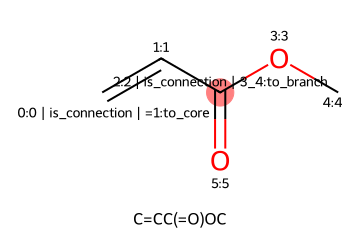


Детальный анализ структуры
Атом соединения: C(2)
Replacement group: 3_4

Соседи атома соединения:
   Сосед 0: C(1) → соседи: ['C(0)']
   Сосед 1: O(3) → соседи: ['C(4)']
   Сосед 2: O(5) → соседи: []
Атомы хвоста по original_index: [3, 4]

Результат: Атомы для удаления: [3, 4]
Ожидалось: [3, 4]


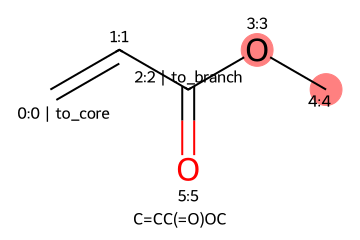

=== Тест на удаление хвоста молекулы methyl_acrylate с индексами ===

Детальный анализ структуры
Атом соединения: C(2)
Replacement group: 3_4

Соседи атома соединения:
   Сосед 0: C(1) → соседи: ['C(0)']
   Сосед 1: O(3) → соседи: ['C(4)']
   Сосед 2: O(5) → соседи: []
Атомы хвоста по original_index: [3, 4]

=== ВЫПОЛНЕНИЕ REDUCE ===
Атомы для удаления: [3, 4]
Связь для разрыва: None
Удалены атомы: [3, 4]
Reduce завершен успешно


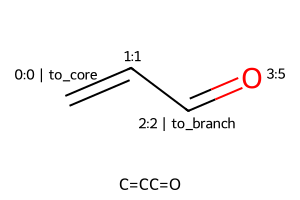

In [8]:

def test_methyl_acrylate_index():
    print("=== Тест на хвост молекулы methyl_acrylate с индексами ===")

    mol = create_methyl_acrylate_with_metadata_indexes()
    co = ChemistryOperations()
    draw_mol(mol, highlight_atoms=[2],
             display_props=['original_index', "is_connection", "replacement_group", "connection_type"])
    # Анализируем структуру
    result = co.analyze_replacement_structure(mol, 2)

    print(f"\nРезультат: Атомы для удаления: {result['atoms']}")
    print(f"Ожидалось: [3, 4]")

    if set(result['atoms']) != {3, 4}:
        print(f"Ожидалось: [3, 4]")
        raise RuntimeError("Тест не пройден")

    return mol, result


def test_methyl_acrylate_index_reduce():
    print("=== Тест на удаление хвоста молекулы methyl_acrylate с индексами ===")
    mol = create_methyl_acrylate_with_metadata_indexes()
    co = ChemistryOperations()
    result = co.reduce(mol, 2)
    return result


small_mol, small_mol_result = test_methyl_acrylate_index()
draw_mol(small_mol, highlight_atoms=small_mol_result['atoms'], display_props=["original_index", "connection_type"])
result_mol = test_methyl_acrylate_index_reduce()
draw_mol(result_mol, display_props=["original_index", "connection_type"])

=== Тест на связь молекулы methyl_acrylate ===


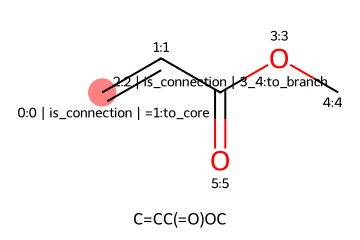


Детальный анализ структуры
Атом соединения: C(0)
Replacement group: =1

Структура replacement_group:
   Атом 0: C → соседи: []

Соседи атома соединения:
   Сосед 0: C(1) → соседи: ['C(2)']
Связь для разрыва: 0
   Для спецификации связи - разрыв связи 0

Результат: Атомы для удаления: [] Связи: 0


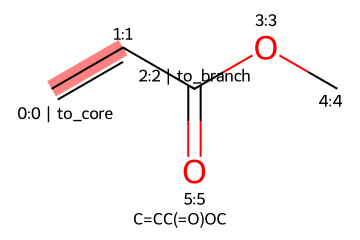

=== Тест на удаление связи молекулы methyl_acrylate с индексами ===

Детальный анализ структуры
Атом соединения: C(0)
Replacement group: =1

Структура replacement_group:
   Атом 0: C → соседи: []

Соседи атома соединения:
   Сосед 0: C(1) → соседи: ['C(2)']
Связь для разрыва: 0
   Для спецификации связи - разрыв связи 0

=== ВЫПОЛНЕНИЕ REDUCE ===
Атомы для удаления: []
Связь для разрыва: 0
Уменьшена кратность связи: 0
Reduce завершен успешно


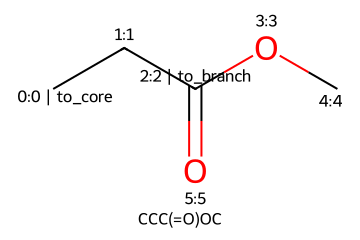

In [9]:

def test_methyl_acrylate_bond():
    print("=== Тест на связь молекулы methyl_acrylate ===")

    mol = create_methyl_acrylate_with_metadata_indexes()
    co = ChemistryOperations()
    draw_mol(mol, highlight_atoms=[0],
             display_props=['original_index', "is_connection", "replacement_group", "connection_type"])
    # Анализируем структуру
    result = co.analyze_replacement_structure(mol, 0)

    print(f"\nРезультат: Атомы для удаления: {result['atoms']} Связи: {result['bond_to_break']}")

    if set(result['atoms']) or result['bond_to_break'] != 0:
        print(f"Ожидалось: [], 0")
        raise RuntimeError("Тест не пройден")

    return mol, result


def test_methyl_acrylate_bond_reduce():
    print("=== Тест на удаление связи молекулы methyl_acrylate с индексами ===")
    mol = create_methyl_acrylate_with_metadata_indexes()
    co = ChemistryOperations()
    result = co.reduce(mol, 0)
    return result


small_mol, small_mol_result = test_methyl_acrylate_bond()
draw_mol(small_mol,
         highlight_atoms=small_mol_result['atoms'], highlight_bonds=[small_mol_result['bond_to_break']],
         display_props=["original_index", "connection_type"])
result_mol = test_methyl_acrylate_bond_reduce()
draw_mol(result_mol, display_props=["original_index", "connection_type"])


=== Тест молекулы ethylenediamine  ===


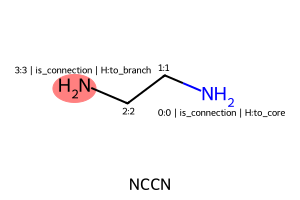


Детальный анализ структуры
Атом соединения: N(3)
Replacement group: H

Соседи атома соединения:
   Сосед 0: C(2) → соседи: ['C(1)']

Поиск соответствующей ветки:

Результат: Атомы для удаления: [], Связи: None


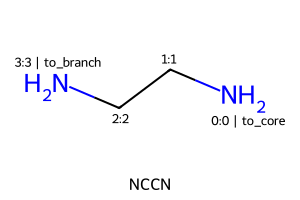

=== Тест уменьшения молекулы ethylenediamine  ===
Исходная SMILES: NCCN
Атом 3 до: H count = 2

Детальный анализ структуры
Атом соединения: N(3)
Replacement group: H

Соседи атома соединения:
   Сосед 0: C(2) → соседи: ['C(1)']

Поиск соответствующей ветки:

=== ВЫПОЛНЕНИЕ REDUCE ===
Атомы для удаления: []
Связь для разрыва: None
Добавлено 1 явных водородов к атому 3
Reduce завершен успешно
SMILES результата: [NH]CCN


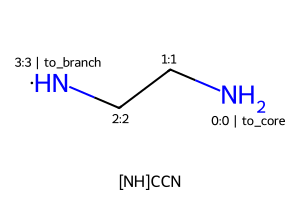

In [10]:
def test_ethylenediamine():
    print("=== Тест молекулы ethylenediamine  ===")

    mol = create_ethylenediamine_with_metadata()
    co = ChemistryOperations()
    draw_mol(mol, highlight_atoms=[3],
             display_props=['original_index', "is_connection", "replacement_group", "connection_type"])
    # Анализируем структуру
    result = co.analyze_replacement_structure(mol, 3)

    print(f"\nРезультат: Атомы для удаления: {result['atoms']}, Связи: {result['bond_to_break']}")

    if set(result['atoms']) or result['bond_to_break'] != None:
        print(f"Ожидалось: []")
        raise RuntimeError("Тест не пройден")

    return mol, result['atoms']


def test_ethylenediamine_reduce():
    print("=== Тест уменьшения молекулы ethylenediamine  ===")

    mol = create_ethylenediamine_with_metadata()
    co = ChemistryOperations()

    # Вывод исходной молекулы
    print(f"Исходная SMILES: {Chem.MolToSmiles(mol)}")
    atom_3_before = mol.GetAtomWithIdx(3)
    print(f"Атом 3 до: H count = {atom_3_before.GetTotalNumHs()}")
    result = co.reduce(mol, 3)

    # Вывод результата
    print(f"SMILES результата: {Chem.MolToSmiles(result)}")
    return result


small_mol, small_mol_result = test_ethylenediamine()
draw_mol(small_mol, highlight_atoms=small_mol_result, display_props=["original_index", "connection_type"])
result_mol = test_ethylenediamine_reduce()
draw_mol(result_mol, display_props=["original_index", "connection_type"])

atom_3_after = result_mol.GetAtomWithIdx(3)
actual = atom_3_after.GetTotalNumHs()
if actual != 1:
    print(f"Ожидалось: 1")
    print(f"Атом 3 после: H count = {actual}")
    raise RuntimeError("Тест не пройден")


=== Тест большой молекулы ===

Детальный анализ структуры
Атом соединения: C(24)
Replacement group: OC

Структура replacement_group:
   Атом 0: O → соседи: ['C(1)']
   Атом 1: C → соседи: ['O(0)']

Соседи атома соединения:
   Сосед 0: C(23) → соседи: ['C(22)']
   Сосед 1: O(25) → соседи: []
   Сосед 2: O(26) → соседи: ['C(27)']

Поиск соответствующей ветки:
   Первый атом replacement: O, степень: 1

   Найден кандидат: O(25)
   Структура не соответствует replacement group

   Найден кандидат: O(26)
   Правильная ветка найдена: [26, 27]

Результат: Атомы для удаления: [26, 27]


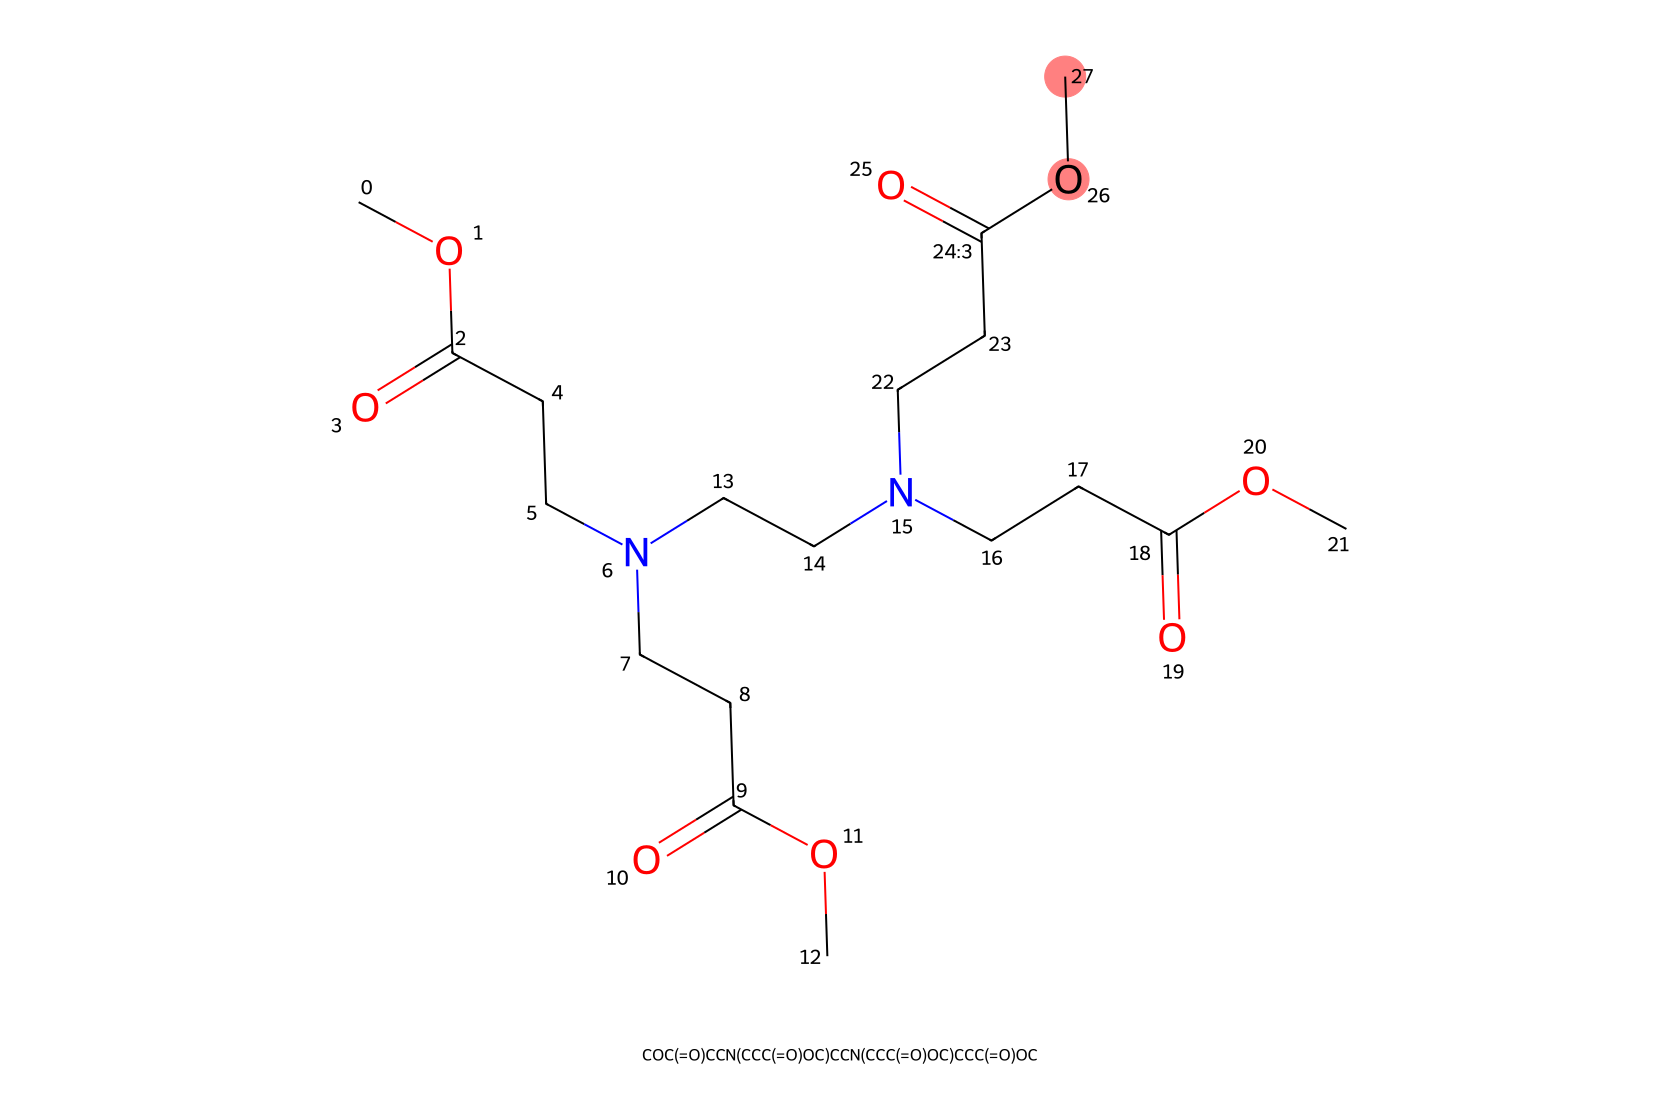

=== Тест уменьшения молекулы large_molecule  ===

Детальный анализ структуры
Атом соединения: C(24)
Replacement group: OC

Структура replacement_group:
   Атом 0: O → соседи: ['C(1)']
   Атом 1: C → соседи: ['O(0)']

Соседи атома соединения:
   Сосед 0: C(23) → соседи: ['C(22)']
   Сосед 1: O(25) → соседи: []
   Сосед 2: O(26) → соседи: ['C(27)']

Поиск соответствующей ветки:
   Первый атом replacement: O, степень: 1

   Найден кандидат: O(25)
   Структура не соответствует replacement group

   Найден кандидат: O(26)
   Правильная ветка найдена: [26, 27]

=== ВЫПОЛНЕНИЕ REDUCE ===
Атомы для удаления: [26, 27]
Связь для разрыва: None
Удалены атомы: [26, 27]
Reduce завершен успешно


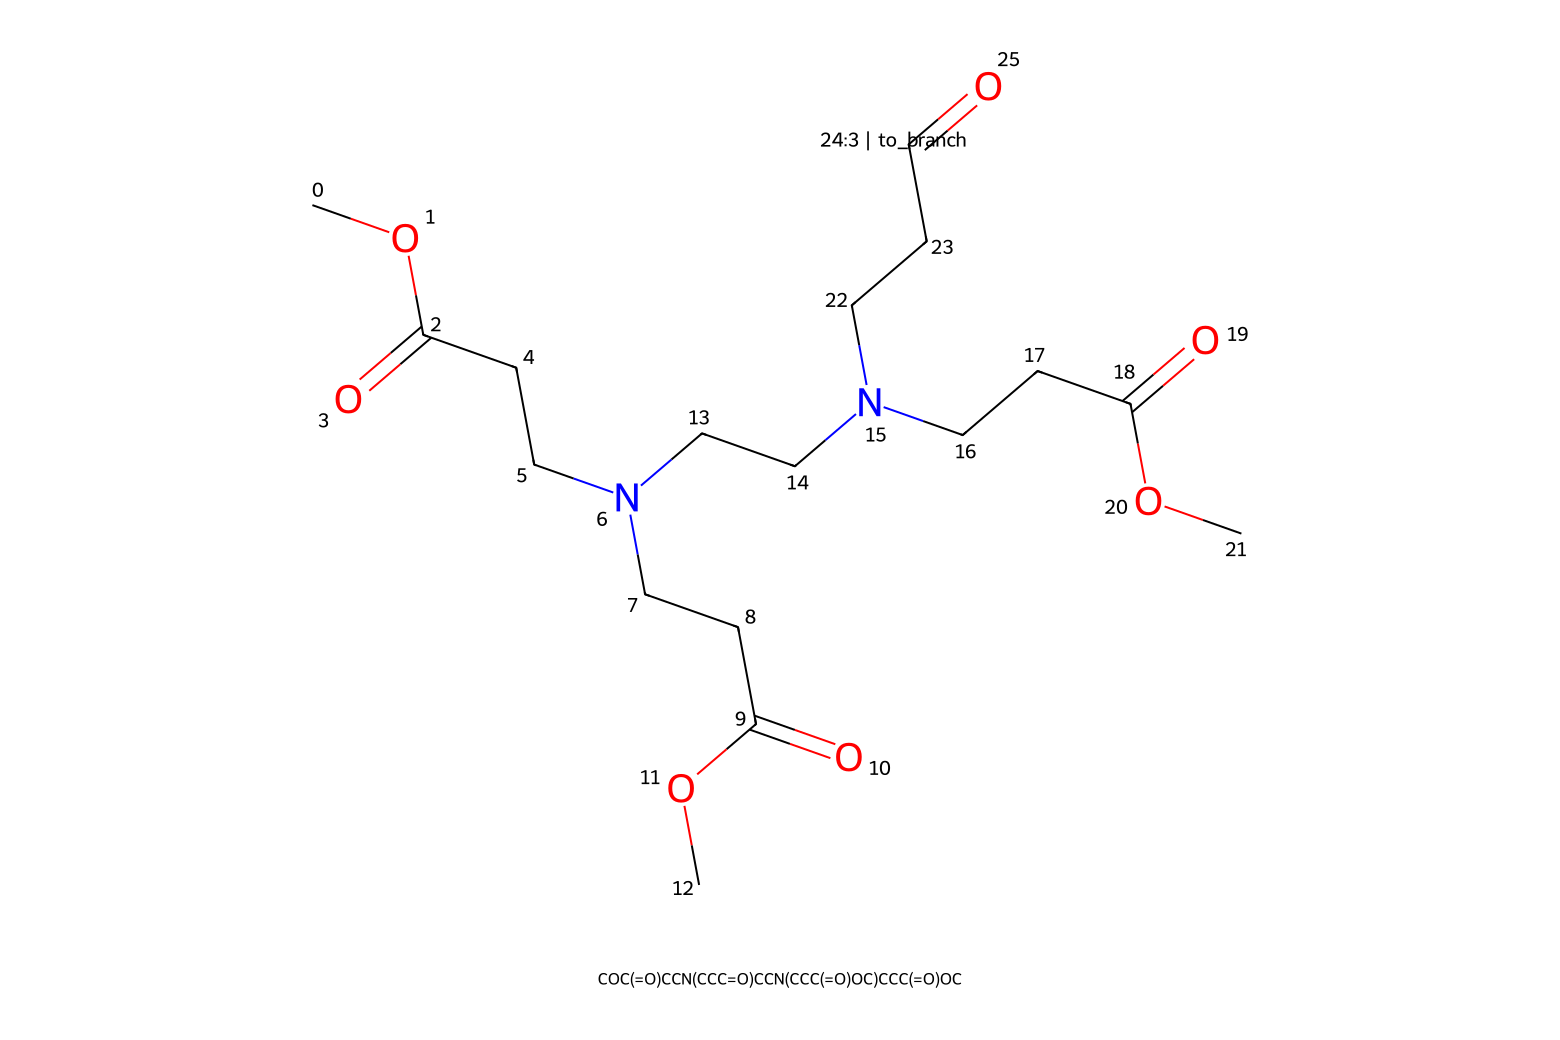

In [11]:


def test_large_molecule():
    print("\n=== Тест большой молекулы ===")

    smiles = "COC(=O)CCN(CCC(=O)OC)CCN(CCC(=O)OC)CCC(=O)OC"
    mol = Chem.MolFromSmiles(smiles)
    co = ChemistryOperations()
    # Добавляем метаданные вручную для нескольких атомов

    # Атом 24 - точка соединения с replacement_group "OC"
    atom24 = mol.GetAtomWithIdx(24)
    atom24.SetProp("original_index", "3")
    atom24.SetProp("is_connection", "true")
    atom24.SetProp("replacement_group", "OC")
    atom24.SetProp("connection_type", "to_branch")

    # Тестируем
    # Анализируем структуру
    result = co.analyze_replacement_structure(mol, 24)

    print(f"\nРезультат: Атомы для удаления: {result['atoms']}")

    if set(result['atoms']) != {26, 27}:
        print(f"Ожидалось: [26, 27]")
        raise RuntimeError("Тест не пройден")

    return mol, result['atoms']


def test_large_molecule_reduce():
    print("=== Тест уменьшения молекулы large_molecule  ===")

    smiles = "COC(=O)CCN(CCC(=O)OC)CCN(CCC(=O)OC)CCC(=O)OC"
    mol = Chem.MolFromSmiles(smiles)
    co = ChemistryOperations()
    # Добавляем метаданные вручную для нескольких атомов

    # Атом 24 - точка соединения с replacement_group "OC"
    atom24 = mol.GetAtomWithIdx(24)
    atom24.SetProp("original_index", "3")
    atom24.SetProp("is_connection", "true")
    atom24.SetProp("replacement_group", "OC")
    atom24.SetProp("connection_type", "to_branch")
    co = ChemistryOperations()

    # Вывод исходной молекулы
    result = co.reduce(mol, 24)
    return result


large_mol, large_mol_result = test_large_molecule()
draw_mol(large_mol, highlight_atoms=large_mol_result, display_props=['original_index'])
large_mol_reduce = test_large_molecule_reduce()
draw_mol(large_mol_reduce, display_props=['original_index', 'connection_type'])

=== Тест молекулы ethylenediamine  ===


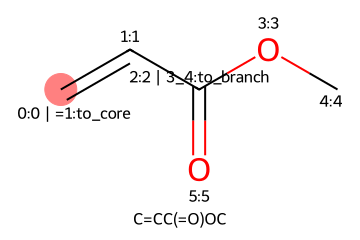

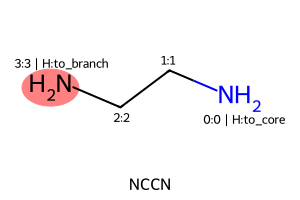


Детальный анализ структуры
Атом соединения: N(3)
Replacement group: H

Соседи атома соединения:
   Сосед 0: C(2) → соседи: ['C(1)']

Поиск соответствующей ветки:

=== ВЫПОЛНЕНИЕ REDUCE ===
Атомы для удаления: []
Связь для разрыва: None
Добавлено 1 явных водородов к атому 3
Reduce завершен успешно

Детальный анализ структуры
Атом соединения: C(0)
Replacement group: =1

Структура replacement_group:
   Атом 0: C → соседи: []

Соседи атома соединения:
   Сосед 0: C(1) → соседи: ['C(2)']
Связь для разрыва: 0
   Для спецификации связи - разрыв связи 0

=== ВЫПОЛНЕНИЕ REDUCE ===
Атомы для удаления: []
Связь для разрыва: 0
Уменьшена кратность связи: 0
Reduce завершен успешно

=== Выполнение connect ===
Базовая молекула: атом 3
Дополнительная молекула: атом 0
После объединения: базовый атом 3, дополнительный атом 4
Connect завершен успешно


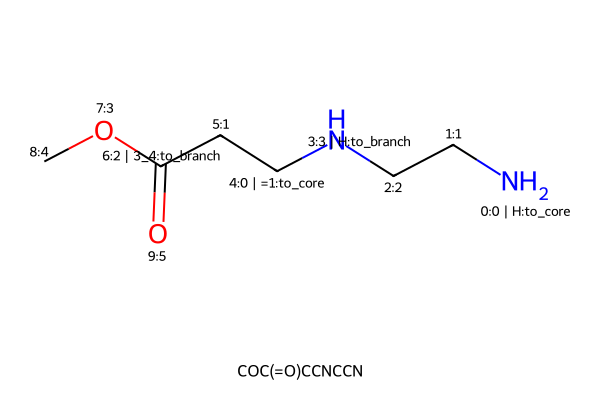

In [12]:


def test_connect1():
    print("=== Тест молекулы ethylenediamine  ===")

    methyl_acrylate = create_methyl_acrylate_with_metadata_indexes()
    ethylenediamine = create_ethylenediamine_with_metadata()
    co = ChemistryOperations()
    draw_mol(methyl_acrylate, highlight_atoms=[0],
             display_props=['original_index', "replacement_group", "connection_type"])
    draw_mol(ethylenediamine, highlight_atoms=[3],
             display_props=['original_index', "replacement_group", "connection_type"])

    result = co.connect(ethylenediamine, 3, methyl_acrylate, 0)

    return result

step1 = test_connect1()
draw_mol(step1, display_props=['original_index', "replacement_group", "connection_type"])

=== Тест молекулы ethylenediamine  ===

Детальный анализ структуры
Атом соединения: N(3)
Replacement group: H

Соседи атома соединения:
   Сосед 0: C(2) → соседи: ['C(1)']

Поиск соответствующей ветки:

=== ВЫПОЛНЕНИЕ REDUCE ===
Атомы для удаления: []
Связь для разрыва: None
Добавлено 1 явных водородов к атому 3
Reduce завершен успешно

Детальный анализ структуры
Атом соединения: C(0)
Replacement group: =1

Структура replacement_group:
   Атом 0: C → соседи: []

Соседи атома соединения:
   Сосед 0: C(1) → соседи: ['C(2)']
Связь для разрыва: 0
   Для спецификации связи - разрыв связи 0

=== ВЫПОЛНЕНИЕ REDUCE ===
Атомы для удаления: []
Связь для разрыва: 0
Уменьшена кратность связи: 0
Reduce завершен успешно

=== Выполнение connect ===
Базовая молекула: атом 3
Дополнительная молекула: атом 0
После объединения: базовый атом 3, дополнительный атом 4
Connect завершен успешно


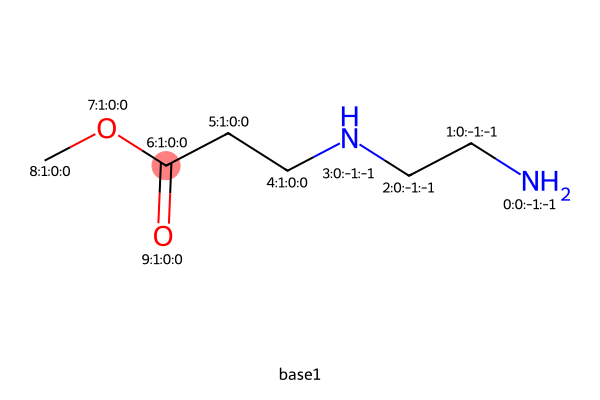

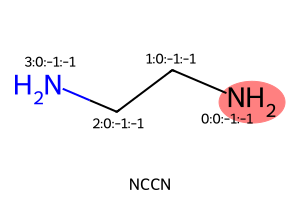


Детальный анализ структуры
Атом соединения: N(3)
Replacement group: H

Соседи атома соединения:
   Сосед 0: C(2) → соседи: ['C(1)']
   Сосед 1: C(4) → соседи: ['C(5)']

Поиск соответствующей ветки:

=== ВЫПОЛНЕНИЕ REDUCE ===
Атомы для удаления: []
Связь для разрыва: None
Добавлено 0 явных водородов к атому 3
Reduce завершен успешно

Детальный анализ структуры
Атом соединения: C(0)
Replacement group: =1

Структура replacement_group:
   Атом 0: C → соседи: []

Соседи атома соединения:
   Сосед 0: C(1) → соседи: ['C(2)']
Связь для разрыва: 0
   Для спецификации связи - разрыв связи 0

=== ВЫПОЛНЕНИЕ REDUCE ===
Атомы для удаления: []
Связь для разрыва: 0
Уменьшена кратность связи: 0
Reduce завершен успешно

=== Выполнение connect ===
Базовая молекула: атом 3
Дополнительная молекула: атом 0
После объединения: базовый атом 3, дополнительный атом 10
Connect завершен успешно


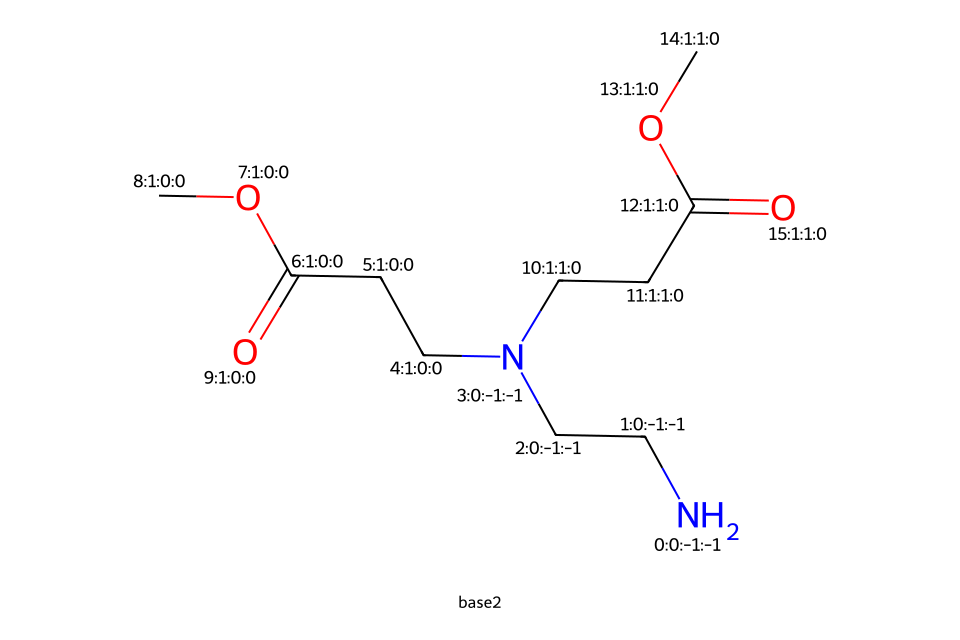


Детальный анализ структуры
Атом соединения: C(6)
Replacement group: 3_4

Соседи атома соединения:
   Сосед 0: C(5) → соседи: ['C(4)']
   Сосед 1: O(7) → соседи: ['C(8)']
   Сосед 2: O(9) → соседи: []
Атомы хвоста по original_index: [7, 8]

=== ВЫПОЛНЕНИЕ REDUCE ===
Атомы для удаления: [7, 8]
Связь для разрыва: None
Удалены атомы: [7, 8]
Reduce завершен успешно

Детальный анализ структуры
Атом соединения: N(0)
Replacement group: H

Соседи атома соединения:
   Сосед 0: C(1) → соседи: ['C(2)']

Поиск соответствующей ветки:

=== ВЫПОЛНЕНИЕ REDUCE ===
Атомы для удаления: []
Связь для разрыва: None
Добавлено 1 явных водородов к атому 0
Reduce завершен успешно

=== Выполнение connect ===
Базовая молекула: атом 6
Дополнительная молекула: атом 0
После объединения: базовый атом 6, дополнительный атом 14
Connect завершен успешно


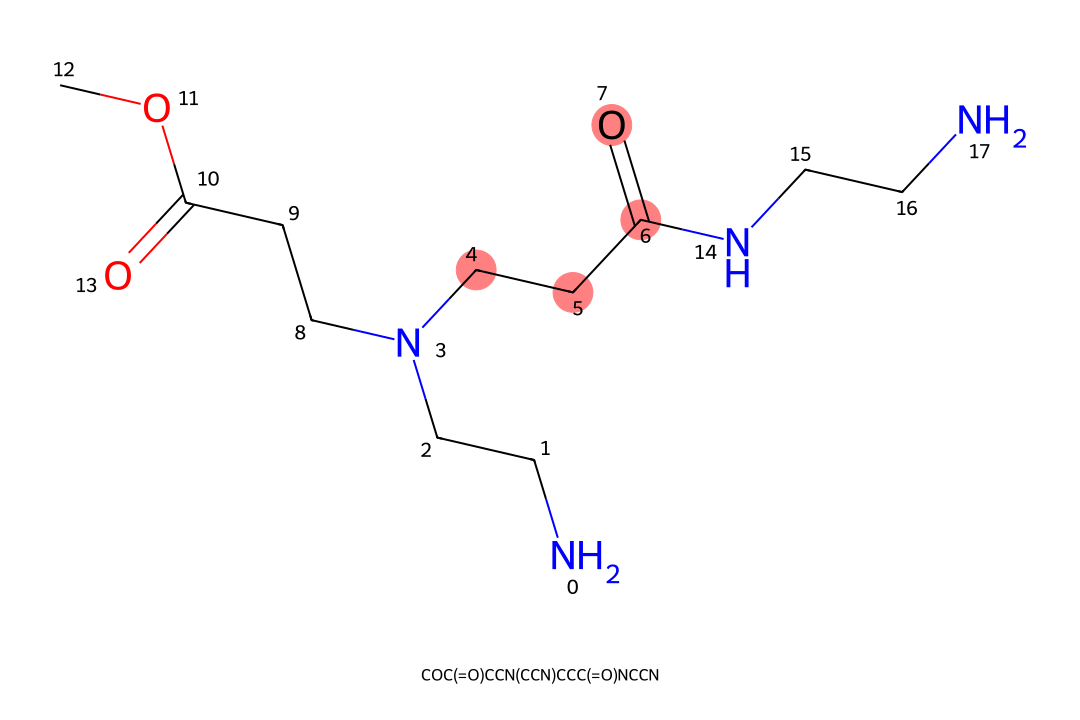

In [13]:

def test_property_connection():
    print("=== Тест молекулы ethylenediamine  ===")

    methyl_acrylate = create_methyl_acrylate_with_metadata_indexes()
    ethylenediamine = create_ethylenediamine_with_metadata()
    co = ChemistryOperations()
    co.set_atom_properties(ethylenediamine, 0,-1,-1)
    base1 = co.connect(ethylenediamine, 3, methyl_acrylate, 0, 1,0,0)
    draw_mol(base1,"base1", highlight_atoms=[6],
             display_props=['generation', "branch", "step"])
    draw_mol(ethylenediamine, highlight_atoms=[0],
             display_props=['generation', "branch", "step"])

    base2 = co.connect(base1, 3, methyl_acrylate, 0, 1,1,0)
    draw_mol(base2,"base2", display_props=['generation', "branch", "step"])

    base3 = co.connect(base2, 6,ethylenediamine, 0, 1,0,1)
    return base3



result = test_property_connection()
from src import IndexTracker
it=IndexTracker(result)
gen1_br0_st0 = it.get_atoms(generations=[1],branches=[0],steps=[0])
draw_mol(result,highlight_atoms=gen1_br0_st0)